
# Lab 6: Fast Fourier Transform (FFT)

* ## Angélica Vanegas C.C 1000290572

 **Exercise** : Chord - musical sound: Do mayor

![Do mayor](https://upload.wikimedia.org/wikipedia/commons/7/79/Major_chord_on_C.png)

Load the Nota_CM_piano.mp3 file from a Do mayor sound:
1. Do the FFT using scipy and Numpy rutines (see notebook)
2. Used the rutine created in class `FT(x,y)`. Modify it and do the FT to the signal. Do you get the same results?


# Solución  1)

In [1]:
!pip install playsound3

In [3]:
from playsound3 import playsound
playsound('Nota_CM_piano.mp3')

In [6]:
import librosa
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

# Load the mp3 file
# sr=None preserves the original sampling rate; otherwise, it defaults to 22050 Hz
signal2, sr = librosa.load('Nota_CM_piano.mp3', sr=None)

print(f"Sample Rate: {sr}")
print(f"Signal Shape: {signal2.shape}")


Sample Rate: 44100
Signal Shape: (152064,)


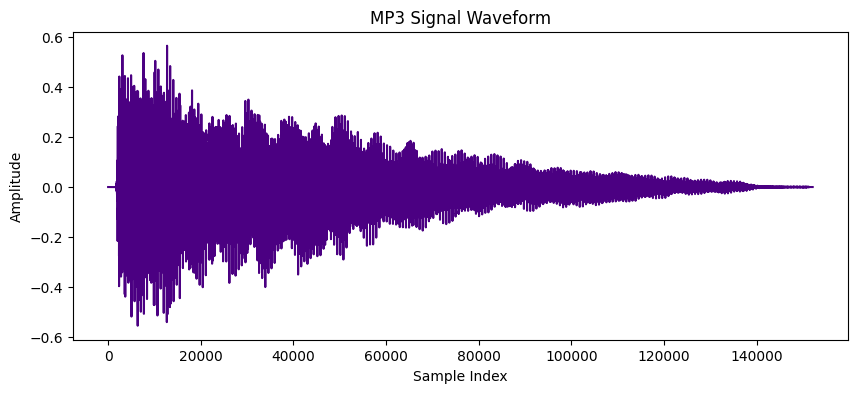

In [10]:
#@title Gráfica de la señal

plt.figure(figsize=(10, 4))
plt.plot(signal2, color = "indigo")
plt.title("MP3 Signal Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

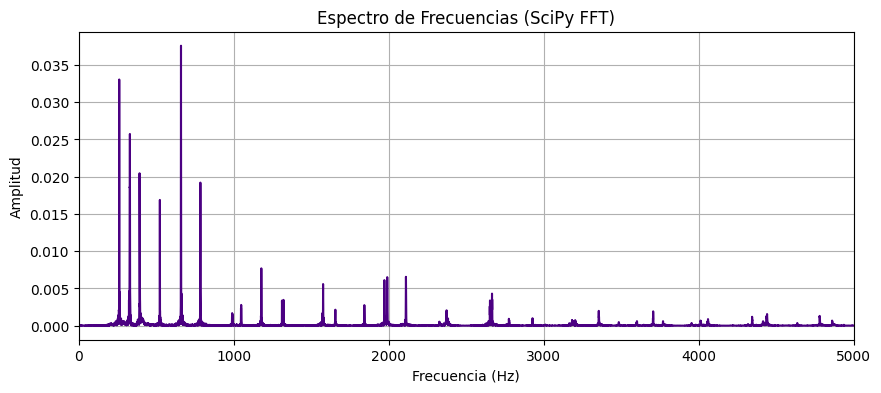

In [42]:
#@title FFT con scipy

N = len(signal2)      # Número de muestras
yf = fft(signal2)     #Transformada de Fourier
xf = fftfreq(N, 1/sr) # Vector de frecuencias, para relacionarlo con yf
amplitud = 2.0/N * np.abs(yf)

# Sólo frecuencias positivas
freqs = xf[:N//2]
amplitud1 = amplitud[:N//2]

# Graficar solo las frecuencias positivas
plt.figure(figsize=(10,4))
plt.plot(freqs, amplitud1, color="indigo")
plt.title("Espectro de Frecuencias (SciPy FFT)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0, 5000)
plt.grid()
plt.show()

# Ahora vamos a ver cual es la frecuencia que corresponde al pico más alto

In [26]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(amplitud1, height=0.015)  #guiandonos de la gráfica para un límite en la amplitud de los picos
primer_pico = peaks[0]
pico_max = peaks[np.argmax(amplitud1[peaks])]

print("Primera frecuencia", freqs[primer_pico], "Hz con Amplitud:", amplitud1[primer_pico])
print("Frecuencia dominante:", freqs[pico_max], "Hz con Amplitud:", amplitud1[pico_max])

Primera frecuencia 261.0085227272727 Hz con Amplitud: 0.033041395
Frecuencia dominante: 659.481534090909 Hz con Amplitud: 0.037575655


El análisis de Fourier permitió identificar una frecuencia fundamental de aproximadamente 261 Hz, correspondiente a la nota Do central. También se observaron armónicos, siendo el más intenso el de 659 Hz, que no corresponde exactamente a un armónico de la fundamental, posiblemente debido a las características acústicas del instrumento y del proceso de grabación.

https://es.wikipedia.org/wiki/Do_(nota)#:~:text=Por%20convenci%C3%B3n%2C%20desde%20principios%20del,frecuencia%20de%20261%2C625%20565%20hercios.

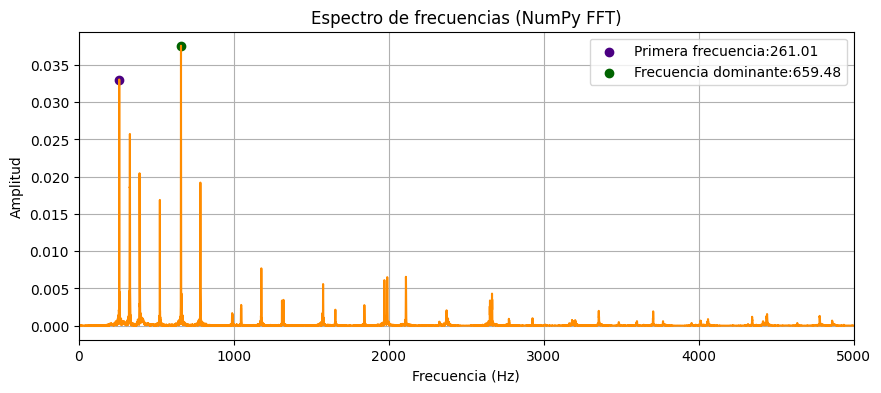

In [27]:
#@title FFT con numpy y graficando la frecuencia máxima

yf2 = np.fft.fft(signal2)
xf2 = np.fft.fftfreq(N, 1/sr)
amplitud2 = 2.0/N * np.abs(yf2)

freqs2 = xf2[:N//2]
amplitud_2 = amplitud2[:N//2]

plt.figure(figsize=(10,4))
plt.scatter(freqs[primer_pico], amplitud1[primer_pico], color="indigo", label= f"Primera frecuencia:{round(freqs[primer_pico],2)}")
plt.scatter(freqs[pico_max], amplitud1[pico_max], color="darkgreen", label= f"Frecuencia dominante:{round(freqs[pico_max],2)}")
plt.plot(freqs2, amplitud_2, color="darkorange")
plt.title("Espectro de frecuencias (NumPy FFT)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0,5000)
plt.legend()
plt.grid()
plt.show()

# 2) Usando la rutina FT(x,y) que se vió en clase

In [32]:
# Rutina del profe

def g(t,w):
    return 1./(2*np.pi)*np.exp(-1j*2*np.pi*w*t)

from scipy import interpolate
import scipy.integrate as integrate
import pandas as pd


def FT(x,y):
    '''Integrate the Fourier Transform of f(t) at frequency w'''

    #Interpolate f(t) to integrate
    f_interp = interpolate.interp1d(x, y, kind='cubic', fill_value='extrapolate')
    ft = lambda t: f_interp(t)

    # range of t to integrate
    t = np.linspace(x.min(), x.max(), 400)

    # FRECUENCIES spectrum to looking for peaks
    w = np.linspace(200,700,500)         #Cambiamos el rango de frecuencias ya que nuestra señal recoge mas frecuencias

    df = []
    for i in range(len(w)):
        ARew = integrate.quad(lambda t: ft(t)*g(t,w[i]).real, t.min(), t.max())[0]
        AImw = integrate.quad(lambda t: ft(t)*g(t,w[i]).imag, t.min(), t.max())[0]
        AMP = np.sqrt(ARew**2 + AImw**2)
        ANG = np.arctan2(AImw, ARew)
        df.append([w[i], ARew, AImw, AMP, ANG])

    # DataFrame
    df = pd.DataFrame(df, columns=['w', 'ReTw', 'ImTw', 'AMP', 'ANG'])
    return df

In [33]:
t = np.arange(N)/sr # Definimos un eje temporal
fft_ = FT(t, signal2)

/tmp/ipykernel_7569/3630200369.py:26: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  ARew = integrate.quad(lambda t: ft(t)*g(t,w[i]).real, t.min(), t.max())[0]
/tmp/ipykernel_7569/3630200369.py:27: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  AImw = integrate.quad(lambda t: ft(t)*g(t,w[i]).imag, t.min(), t.max())[0]
/tmp/ipykernel_7569/3630200369.py:27: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  AImw = integrate.quad(lambda t: ft(t)*g(t,w[i]).imag, t.min(), t.max())[0]
/tmp/ipykernel_7569/3630200369.py:26: Inte

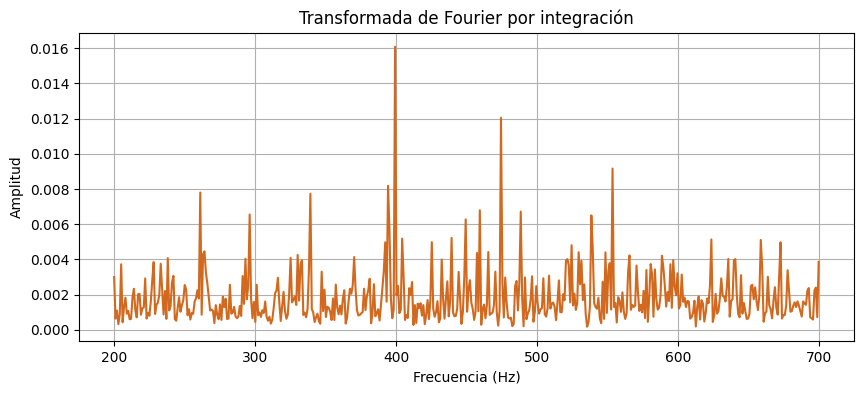

In [35]:
#@title Gráfica con la rutina del profe

plt.figure(figsize=(10,4))
plt.plot(fft_['w'], fft_['AMP'], color = "chocolate")
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.title('Transformada de Fourier por integración')

plt.grid()
plt.show()

# Hagamos un filtro en el dataframe para buscar la amplitud de la frecuencia fundamental que ya conocemos

In [37]:
fft__filtrado = fft_[(fft_["w"] >= 250) & (fft_["w"] <= 265)]
print(fft__filtrado)

             w      ReTw      ImTw       AMP       ANG
50  250.100200  0.002448  0.000698  0.002546  0.277546
51  251.102204 -0.001804 -0.001426  0.002299 -2.472622
52  252.104208 -0.000733  0.000392  0.000831  2.650032
53  253.106212 -0.000569  0.001023  0.001170  2.078408
54  254.108216  0.000088 -0.000578  0.000585 -1.419566
55  255.110220 -0.000756 -0.000588  0.000958 -2.480972
56  256.112224 -0.000646 -0.000647  0.000914 -2.354993
57  257.114228  0.001595 -0.000073  0.001597 -0.045433
58  258.116232 -0.001764 -0.000308  0.001791 -2.968778
59  259.118236  0.002239  0.000212  0.002249  0.094488
60  260.120240  0.001255  0.001266  0.001782  0.789699
61  261.122244 -0.001378 -0.007680  0.007802 -1.748326
62  262.124248  0.000127 -0.000852  0.000861 -1.422701
63  263.126253 -0.002166  0.003723  0.004308  2.097704
64  264.128257  0.003988  0.001993  0.004459  0.463457


In [41]:
print(fft_.loc[61])

w       261.122244
ReTw     -0.001378
ImTw     -0.007680
AMP       0.007802
ANG      -1.748326
Name: 61, dtype: float64


Como podemos ver la frecuencia que mas se acerca a la fundamental está en el índice 61 del dataframe la cual es $\approx$ 261.122244 y corresponde a la amplitud $\approx$ 0.007802. La amplitud resultó menor debido a las aproximaciones introducidas por la interpolación y el cálculo numérico de las integrales.

Además, fue necesario reducir el número de puntos del arreglo w para disminuir el tiempo de cómputo (se intentó con un linspace de (0, 1000, 1000) pero se demoró mas de 4 min corriendo el código) lo que redujo la cantidad de frecuencias y como vemos el espectro quedó menos definido, con mayor cantidad de ruido en comparación con el obtenido mediante la FFT de scipy o numpy.

Nota 3.5 Revisado... Entrega tarde. Quizás mal el git push!